<a href="https://colab.research.google.com/github/IImcl/tp53-vus-prioritization-/blob/main/tp53_vus_prioritization_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install pandas numpy requests tqdm

In [2]:
import os, gzip, json, time, re
import numpy as np
import pandas as pd
import requests
from tqdm import tqdm

# ===== Paths / Cache =====
CACHE_DIR = "cache_tp53"
os.makedirs(CACHE_DIR, exist_ok=True)

CLINVAR_GZ = os.path.join(CACHE_DIR, "variant_summary.txt.gz")
TP53_CLINVAR_CSV = os.path.join(CACHE_DIR, "tp53_clinvar_grch38.csv")
PRED_DF_CSV = os.path.join(CACHE_DIR, "pred_df_vep_tp53.csv")
TP53_MISSENSE_CSV = os.path.join(CACHE_DIR, "tp53_missense_merged.csv")
FINAL_CSV = os.path.join(CACHE_DIR, "tp53_final_missense_v2.csv")

# ===== Helpers =====
def clean_chrom(ch):
    if pd.isna(ch):
        return ch
    return str(ch).replace("chr", "").strip()

def make_vep_row(chrom, pos, ref, alt):
    return f"{clean_chrom(chrom)} {int(pos)} . {str(ref).upper()} {str(alt).upper()} . . ."

def clin_group(clinsig):
    if clinsig is None or (isinstance(clinsig, float) and np.isnan(clinsig)):
        return "other"
    s = str(clinsig).lower()
    if "uncertain" in s or "vus" in s:
        return "VUS"
    if "likely pathogenic" in s:
        return "likely_pathogenic"
    if "pathogenic" in s:
        return "pathogenic"
    if "likely benign" in s:
        return "likely_benign"
    if "benign" in s:
        return "benign"
    return "other"

print("CELL 2 OK ✅", "Cache:", CACHE_DIR)


CELL 2 OK ✅ Cache: cache_tp53


In [3]:
# =========================
# CELL 3 (Resume) — Continue ClinVar download (supports resume)
# =========================
import os
import requests

url = "https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/variant_summary.txt.gz"

existing = os.path.getsize(CLINVAR_GZ) if os.path.exists(CLINVAR_GZ) else 0

# Get total size from server
head = requests.head(url, timeout=30, allow_redirects=True)
head.raise_for_status()
total = int(head.headers.get("Content-Length", 0))

if total > 0 and existing >= total:
    print("ClinVar gz already complete ✅", CLINVAR_GZ, "size:", existing)
else:
    print(f"Resuming download... existing={existing/1e6:.1f}MB total={total/1e6:.1f}MB")

    headers = {"Range": f"bytes={existing}-"} if existing > 0 else {}
    mode = "ab" if existing > 0 else "wb"

    r = requests.get(url, stream=True, headers=headers, timeout=60)
    r.raise_for_status()

    downloaded = existing
    with open(CLINVAR_GZ, mode) as f:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                downloaded += len(chunk)
                if total > 0:
                    print(f"\r{downloaded/total*100:.1f}%  ({downloaded/1e6:.1f}/{total/1e6:.1f} MB)", end="")

    print("\nDone ✅ Saved:", CLINVAR_GZ, "size:", os.path.getsize(CLINVAR_GZ))


Resuming download... existing=0.0MB total=412.9MB
100.0%  (412.9/412.9 MB)
Done ✅ Saved: cache_tp53/variant_summary.txt.gz size: 412880955


In [4]:
# =========================
# CELL 4 — Parse ClinVar (TP53 + GRCh38) robustly, build vep_row
# =========================
import gzip
import pandas as pd
import numpy as np
import os
import re

if not os.path.exists(CLINVAR_GZ):
    raise FileNotFoundError(f"ClinVar file not found: {CLINVAR_GZ}")

size_mb = os.path.getsize(CLINVAR_GZ) / 1e6
print(f"ClinVar gz size: {size_mb:.1f} MB -> {CLINVAR_GZ}")

# Read header
with gzip.open(CLINVAR_GZ, "rt") as f:
    header = f.readline().rstrip("\n").split("\t")

def pick_col(cands):
    for c in cands:
        if c in header:
            return c
    return None

assembly_col = pick_col(["Assembly"])
gene_col     = pick_col(["GeneSymbol", "GeneSymbol(s)"])
chrom_col    = pick_col(["Chromosome"])
pos_col      = pick_col(["Start", "StartVCF", "PositionVCF"])
ref_col      = pick_col(["ReferenceAlleleVCF", "ReferenceAllele"])
alt_col      = pick_col(["AlternateAlleleVCF", "AlternateAllele"])
clinsig_col  = pick_col(["ClinicalSignificance", "Clinical significance (Last reviewed)"])

need = [assembly_col, gene_col, chrom_col, pos_col, ref_col, alt_col, clinsig_col]
if any(c is None for c in need):
    missing = [name for name, c in zip(
        ["Assembly","GeneSymbol","Chromosome","Start/PositionVCF","ReferenceAllele","AlternateAllele","ClinicalSignificance"],
        need
    ) if c is None]
    raise ValueError(f"Missing required columns in ClinVar header: {missing}")

usecols = [assembly_col, gene_col, chrom_col, pos_col, ref_col, alt_col, clinsig_col]

# Regex: match TP53 as a token (handles "TP53", "TP53;WRAP53", etc.)
tp53_token = re.compile(r"(^|[;,\s])TP53($|[;,\s])", flags=re.IGNORECASE)
base_pat = re.compile(r"^[ACGT]$", flags=re.IGNORECASE)

def first_allele(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return ""
    s = str(x).strip().upper()
    # keep first allele if multiple (comma or slash separated)
    s = re.split(r"[,/]", s)[0].strip()
    return s

chunksize = 200_000
kept = []

count_gene = 0
count_asm = 0
count_both = 0
count_both_after_snv = 0

for chunk in pd.read_csv(
    CLINVAR_GZ,
    sep="\t",
    compression="gzip",
    dtype=str,
    usecols=usecols,
    chunksize=chunksize,
    low_memory=False
):
    asm = chunk[assembly_col].fillna("")
    gene = chunk[gene_col].fillna("")

    m_asm = asm.str.contains("GRCh38", case=False, na=False)
    m_gene = gene.str.contains(tp53_token, na=False, regex=True)

    count_gene += int(m_gene.sum())
    count_asm  += int(m_asm.sum())

    sub = chunk[m_asm & m_gene].copy()
    count_both += len(sub)
    if sub.empty:
        continue

    sub["chrom"] = sub[chrom_col].astype(str).str.replace("chr", "", regex=False).str.strip()
    sub["pos"]   = pd.to_numeric(sub[pos_col], errors="coerce")

    sub["ref"] = sub[ref_col].apply(first_allele)
    sub["alt"] = sub[alt_col].apply(first_allele)

    m_pos = sub["pos"].notna()
    m_ref = sub["ref"].str.match(base_pat, na=False)
    m_alt = sub["alt"].str.match(base_pat, na=False)
    sub = sub[m_pos & m_ref & m_alt].copy()
    count_both_after_snv += len(sub)

    if sub.empty:
        continue

    sub["clinical_significance"] = sub[clinsig_col]
    sub["clin_group"] = sub["clinical_significance"].apply(clin_group)

    sub["vep_row"] = (
        sub["chrom"].astype(str) + " " +
        sub["pos"].astype("Int64").astype(str) +
        " . " + sub["ref"] + " " + sub["alt"] + " . . ."
    )

    kept.append(sub[["chrom","pos","ref","alt","clinical_significance","clin_group","vep_row"]])

print("Counts (rough):")
print("  TP53 matches (any assembly):", count_gene)
print("  GRCh38 matches (any gene):", count_asm)
print("  TP53 & GRCh38 rows (before SNV filter):", count_both)
print("  TP53 & GRCh38 rows (after SNV filter):", count_both_after_snv)

if len(kept) == 0:
    print("❌ Still 0 rows saved. Next step: we will print the exact header + sample TP53 rows for debugging.")
else:
    tp53_df = pd.concat(kept, ignore_index=True).drop_duplicates(subset=["vep_row"])
    tp53_df.rename(columns={"chrom":"Chromosome","pos":"Position","ref":"Ref","alt":"Alt"}, inplace=True)
    tp53_df.to_csv(TP53_CLINVAR_CSV, index=False)
    print("✅ Saved:", TP53_CLINVAR_CSV)
    print("Rows saved:", len(tp53_df))
    print("clin_group counts:\n", tp53_df["clin_group"].value_counts(dropna=False))
    print("Example vep_row:", tp53_df["vep_row"].iloc[0])


ClinVar gz size: 412.9 MB -> cache_tp53/variant_summary.txt.gz


/tmp/ipython-input-1944109155.py:77: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  m_gene = gene.str.contains(tp53_token, na=False, regex=True)
/tmp/ipython-input-1944109155.py:77: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  m_gene = gene.str.contains(tp53_token, na=False, regex=True)
/tmp/ipython-input-1944109155.py:77: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  m_gene = gene.str.contains(tp53_token, na=False, regex=True)
/tmp/ipython-input-1944109155.py:77: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  m_gene = gene.str.contains(tp53_token, na=False, regex=True)
/tmp/ipython-input-1944109155.py:77: UserWarning: This pattern is in

Counts (rough):
  TP53 matches (any assembly): 7622
  GRCh38 matches (any gene): 4156969
  TP53 & GRCh38 rows (before SNV filter): 3779
  TP53 & GRCh38 rows (after SNV filter): 2698
✅ Saved: cache_tp53/tp53_clinvar_grch38.csv
Rows saved: 2698
clin_group counts:
 clin_group
likely_benign        931
VUS                  723
pathogenic           673
likely_pathogenic    231
benign               108
other                 32
Name: count, dtype: int64
Example vep_row: 17 7674221 . G A . . .


/tmp/ipython-input-1944109155.py:77: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  m_gene = gene.str.contains(tp53_token, na=False, regex=True)


In [5]:
# =========================
# CELL 5 — VEP REST (batch) annotate variants -> pred_df_vep_tp53.csv
# =========================
import os, time, json
import pandas as pd
import numpy as np
import requests
from tqdm import tqdm

if not os.path.exists(TP53_CLINVAR_CSV):
    raise FileNotFoundError(f"Missing: {TP53_CLINVAR_CSV}. Run CELL 4 first.")

# If already computed, load it
if os.path.exists(PRED_DF_CSV) and os.path.getsize(PRED_DF_CSV) > 0:
    pred_df = pd.read_csv(PRED_DF_CSV)
    print("Loaded existing ✅", PRED_DF_CSV, "rows:", len(pred_df))
else:
    tp53_df = pd.read_csv(TP53_CLINVAR_CSV)
    variants = tp53_df["vep_row"].dropna().astype(str).tolist()

    if len(variants) == 0:
        raise ValueError("No variants found in TP53_CLINVAR_CSV (vep_row is empty).")

    VEP_URL = "https://rest.ensembl.org/vep/human/region"
    session = requests.Session()

    def vep_post(batch):
        headers = {
            "Content-Type": "application/json",
            "Accept": "application/json",
            "User-Agent": "tp53-vus-prioritization-colab"
        }
        payload = {"variants": batch}
        backoff = 2
        for attempt in range(8):
            try:
                r = session.post(VEP_URL, headers=headers, data=json.dumps(payload), timeout=120)
                if r.status_code == 429:
                    time.sleep(backoff)
                    backoff = min(backoff * 2, 60)
                    continue
                r.raise_for_status()
                return r.json()
            except Exception as e:
                time.sleep(backoff)
                backoff = min(backoff * 2, 60)
        raise RuntimeError("VEP request failed repeatedly.")

    def pick_best_tc(tcs):
        # Prefer canonical transcript; otherwise first with protein_start & amino_acids
        if not tcs:
            return None
        canon = [tc for tc in tcs if str(tc.get("canonical", "")).lower() in ("1", "true")]
        pool = canon if canon else tcs
        for tc in pool:
            if tc.get("protein_start") is not None and tc.get("amino_acids"):
                return tc
        return pool[0]

    def build_hgvsp_key(tc):
        h = tc.get("hgvsp")
        if isinstance(h, str) and h.startswith("p."):
            return h
        aa = tc.get("amino_acids")
        pos = tc.get("protein_start")
        if aa and pos:
            parts = str(aa).split("/")
            if len(parts) == 2:
                return f"p.{parts[0]}{int(pos)}{parts[1]}"
        return None

    batch_size = 200
    rows = []

    for i in tqdm(range(0, len(variants), batch_size), desc="VEP batches"):
        batch = variants[i:i+batch_size]
        data = vep_post(batch)

        for entry in data:
            inp = entry.get("input")
            tcs = entry.get("transcript_consequences", []) or []

            is_missense = any("missense_variant" in (tc.get("consequence_terms") or []) for tc in tcs)
            best_tc = pick_best_tc(tcs) if tcs else None

            rec = {
                "vep_row": inp,
                "is_missense": bool(is_missense),
                "position": None,
                "ref_aa": None,
                "alt_aa": None,
                "hgvsp": None,
                "sift_score": None,
                "sift_prediction": None,
                "polyphen_score": None,
                "polyphen_prediction": None,
            }

            if best_tc:
                rec["position"] = best_tc.get("protein_start")
                aa = best_tc.get("amino_acids")
                if aa and "/" in str(aa):
                    a0, a1 = str(aa).split("/", 1)
                    rec["ref_aa"] = a0
                    rec["alt_aa"] = a1

                rec["hgvsp"] = build_hgvsp_key(best_tc)

                rec["sift_score"] = best_tc.get("sift_score")
                rec["sift_prediction"] = best_tc.get("sift_prediction")
                rec["polyphen_score"] = best_tc.get("polyphen_score")
                rec["polyphen_prediction"] = best_tc.get("polyphen_prediction")

            rows.append(rec)

    pred_df = pd.DataFrame(rows).drop_duplicates(subset=["vep_row"])
    pred_df.to_csv(PRED_DF_CSV, index=False)
    print("Saved ✅", PRED_DF_CSV, "rows:", len(pred_df))

    miss_frac_sift = pred_df["sift_score"].isna().mean()
    miss_frac_poly = pred_df["polyphen_score"].isna().mean()
    print("Missing SIFT fraction:", float(miss_frac_sift))
    print("Missing PolyPhen fraction:", float(miss_frac_poly))
    print(pred_df.head(3))


VEP batches: 100%|██████████| 14/14 [01:12<00:00,  5.19s/it]

Saved ✅ cache_tp53/pred_df_vep_tp53.csv rows: 2698
Missing SIFT fraction: 0.4747961452928095
Missing PolyPhen fraction: 0.9058561897702001
                  vep_row  is_missense  position ref_aa alt_aa    hgvsp  \
0  17 7674221 . G A . . .         True     248.0      R      W  p.R248W   
1  17 7674191 . C T . . .         True     258.0      E      K  p.E258K   
2  17 7674230 . C A . . .         True     245.0      G      C  p.G245C   

   sift_score sift_prediction  polyphen_score polyphen_prediction  
0         0.0     deleterious             NaN                None  
1         0.0     deleterious             NaN                None  
2         0.0     deleterious             NaN                None  


In [6]:
# =========================
# CELL 6 — Merge ClinVar + VEP, then filter missense, save tp53_missense_merged.csv
# =========================
import os
import pandas as pd

if not os.path.exists(TP53_CLINVAR_CSV):
    raise FileNotFoundError(f"Missing: {TP53_CLINVAR_CSV}. Run CELL 4.")
if not os.path.exists(PRED_DF_CSV):
    raise FileNotFoundError(f"Missing: {PRED_DF_CSV}. Run CELL 5.")

tp53_df = pd.read_csv(TP53_CLINVAR_CSV)
pred_df = pd.read_csv(PRED_DF_CSV)

merged = tp53_df.merge(pred_df, on="vep_row", how="left")

print("Merged rows:", len(merged))
print("Rows with VEP annotation:", merged["is_missense"].notna().sum())

tp53_missense = merged[merged["is_missense"] == True].copy()

# keep only rows with a usable protein change key
tp53_missense = tp53_missense[tp53_missense["hgvsp"].notna()].copy()

tp53_missense.to_csv(TP53_MISSENSE_CSV, index=False)
print("✅ Saved:", TP53_MISSENSE_CSV)
print("Missense rows:", len(tp53_missense))
print("clin_group counts:\n", tp53_missense["clin_group"].value_counts(dropna=False))
print(tp53_missense[["vep_row","hgvsp","sift_score","polyphen_score","clin_group"]].head(5))


Merged rows: 2698
Rows with VEP annotation: 2698
✅ Saved: cache_tp53/tp53_missense_merged.csv
Missense rows: 1434
clin_group counts:
 clin_group
VUS                  585
pathogenic           514
likely_pathogenic    160
likely_benign        132
benign                31
other                 12
Name: count, dtype: int64
                  vep_row    hgvsp  sift_score  polyphen_score  \
0  17 7674221 . G A . . .  p.R248W        0.00             NaN   
1  17 7674191 . C T . . .  p.E258K        0.00             NaN   
2  17 7674230 . C A . . .  p.G245C        0.00             NaN   
3  17 7674208 . A G . . .  p.L252P        0.00             NaN   
4  17 7676154 . G C . . .   p.P72R        0.14           0.047   

          clin_group  
0         pathogenic  
1  likely_pathogenic  
2         pathogenic  
3         pathogenic  
4             benign  


In [7]:
# =========================
# CELL 7 — Build hgvsp_key (p.R248W) for AlphaMissense merge
# =========================
import os
import pandas as pd
import re

if not os.path.exists(TP53_MISSENSE_CSV):
    raise FileNotFoundError(f"Missing: {TP53_MISSENSE_CSV}. Run CELL 6 first.")

df = pd.read_csv(TP53_MISSENSE_CSV)

def normalize_hgvsp(h):
    if pd.isna(h):
        return None
    s = str(h).strip()
    # keep only the "p.X123Y" part if extra text exists
    m = re.search(r"(p\.[A-Za-z\*]+[0-9]+[A-Za-z\*]+)", s)
    return m.group(1) if m else None

df["hgvsp_key"] = df["hgvsp"].apply(normalize_hgvsp)

before = len(df)
df = df[df["hgvsp_key"].notna()].copy()
after = len(df)

OUT_READY = os.path.join(CACHE_DIR, "tp53_missense_ready_for_alphamissense.csv")
df.to_csv(OUT_READY, index=False)

print("✅ Saved:", OUT_READY)
print("Rows before:", before, "| after (valid hgvsp_key):", after)
print("Example hgvsp_key values:", df["hgvsp_key"].head(5).tolist())


✅ Saved: cache_tp53/tp53_missense_ready_for_alphamissense.csv
Rows before: 1434 | after (valid hgvsp_key): 1434
Example hgvsp_key values: ['p.R248W', 'p.E258K', 'p.G245C', 'p.L252P', 'p.P72R']


In [8]:
# =========================
# CELL 8C — Download AlphaMissense aa_substitutions.tsv.gz into cache (resume)
# =========================
import os

os.makedirs(CACHE_DIR, exist_ok=True)

AM_AA_URL = "https://zenodo.org/records/10813168/files/AlphaMissense_aa_substitutions.tsv.gz?download=1"
AM_AA_PATH = os.path.join(CACHE_DIR, "AlphaMissense_aa_substitutions.tsv.gz")

!wget -c -O "{AM_AA_PATH}" "{AM_AA_URL}"
!ls -lh "{AM_AA_PATH}"

--2025-12-29 17:58:13--  https://zenodo.org/records/10813168/files/AlphaMissense_aa_substitutions.tsv.gz?download=1
Resolving zenodo.org (zenodo.org)... 188.185.43.153, 137.138.52.235, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1207278510 (1.1G) [application/octet-stream]
Saving to: ‘cache_tp53/AlphaMissense_aa_substitutions.tsv.gz’

cache_tp53/AlphaMis 100%[===================>]   1.12G  1.02MB/s    in 21m 7s  

2025-12-29 18:19:21 (931 KB/s) - ‘cache_tp53/AlphaMissense_aa_substitutions.tsv.gz’ saved [1207278510/1207278510]

-rw-r--r-- 1 root root 1.2G Dec 29 18:19 cache_tp53/AlphaMissense_aa_substitutions.tsv.gz


In [9]:
# =========================
# CELL 9A — Inspect AlphaMissense file (first lines + delimiter)
# =========================
import os, gzip

AM_AA_PATH = os.path.join(CACHE_DIR, "AlphaMissense_aa_substitutions.tsv.gz")
if not os.path.exists(AM_AA_PATH):
    raise FileNotFoundError(f"Missing: {AM_AA_PATH}")

print("File:", AM_AA_PATH, "| size(MB):", os.path.getsize(AM_AA_PATH)/1e6)

lines = []
with gzip.open(AM_AA_PATH, "rt") as f:
    for line in f:
        if line.strip() == "":
            continue
        lines.append(line.rstrip("\n"))
        if len(lines) >= 12:
            break

print("\nFirst 12 non-empty lines (trimmed to 220 chars):")
for i, l in enumerate(lines):
    show = l[:220] + (" ..." if len(l) > 220 else "")
    print(f"[{i}] {show}")

# Find first non-comment line as "likely header"
header_line = None
for l in lines:
    if not l.lstrip().startswith("#"):
        header_line = l
        break

if header_line is None:
    print("\n❌ Could not find a non-comment header line in the first 12 lines.")
else:
    tabs = header_line.count("\t")
    commas = header_line.count(",")
    sep = "\t" if tabs >= commas else ","
    print("\nLikely header line delimiter counts:")
    print("  tabs:", tabs, "| commas:", commas)
    print("  detected sep:", repr(sep))
    print("  header preview:", header_line[:220] + (" ..." if len(header_line) > 220 else ""))


File: cache_tp53/AlphaMissense_aa_substitutions.tsv.gz | size(MB): 1207.27851

First 12 non-empty lines (trimmed to 220 chars):
[0] # Copyright 2023 DeepMind Technologies Limited
[1] #
[2] # Licensed under CC BY-NC-SA 4.0 license
[3] uniprot_id	protein_variant	am_pathogenicity	am_class
[4] A0A024R1R8	M1A	0.4673	ambiguous
[5] A0A024R1R8	M1C	0.3828	ambiguous
[6] A0A024R1R8	M1D	0.8267	pathogenic
[7] A0A024R1R8	M1E	0.5236	ambiguous
[8] A0A024R1R8	M1F	0.2753	benign
[9] A0A024R1R8	M1G	0.5476	ambiguous
[10] A0A024R1R8	M1H	0.5517	ambiguous
[11] A0A024R1R8	M1I	0.321	benign

Likely header line delimiter counts:
  tabs: 3 | commas: 0
  detected sep: '\t'
  header preview: uniprot_id	protein_variant	am_pathogenicity	am_class


In [10]:
# =========================
# CELL 9B — Extract TP53 (P04637) from AlphaMissense file (skip comment lines) -> alphamissense_tp53_clean.csv
# =========================
import os, re, gzip
import pandas as pd
import numpy as np

AM_AA_PATH = os.path.join(CACHE_DIR, "AlphaMissense_aa_substitutions.tsv.gz")
AM_TP53_CLEAN = os.path.join(CACHE_DIR, "alphamissense_tp53_clean.csv")

if not os.path.exists(AM_AA_PATH):
    raise FileNotFoundError(f"Missing: {AM_AA_PATH}")

# Find how many comment lines to skip (starting with '#')
skip = 0
with gzip.open(AM_AA_PATH, "rt") as f:
    for line in f:
        if line.startswith("#"):
            skip += 1
        else:
            break

print("Skipping comment lines:", skip)

pat = re.compile(r"(p\.[A-Za-z\*]+[0-9]+[A-Za-z\*]+)")
def to_hgvsp_key(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    m = pat.search(s)
    if m:
        return m.group(1)
    # Format like "R248W" -> "p.R248W"
    if re.fullmatch(r"[A-Za-z\*]+[0-9]+[A-Za-z\*]+", s):
        return "p." + s
    return None

chunksize = 500_000
out_parts = []

for chunk in pd.read_csv(
    AM_AA_PATH,
    sep="\t",
    compression="gzip",
    skiprows=skip,
    dtype={"uniprot_id": str, "protein_variant": str, "am_pathogenicity": str, "am_class": str},
    chunksize=chunksize,
    low_memory=False
):
    sub = chunk[chunk["uniprot_id"].astype(str).str.strip().eq("P04637")].copy()
    if sub.empty:
        continue

    tmp = pd.DataFrame()
    tmp["hgvsp_key"] = sub["protein_variant"].apply(to_hgvsp_key)
    tmp["alphamissense_score"] = pd.to_numeric(sub["am_pathogenicity"], errors="coerce")
    tmp["alphamissense_class"] = sub["am_class"].astype(str)

    tmp = tmp[tmp["hgvsp_key"].notna()]
    out_parts.append(tmp)

if len(out_parts) == 0:
    raise ValueError("No TP53 (P04637) rows found. (Unexpected)")

am_tp53 = pd.concat(out_parts, ignore_index=True).drop_duplicates(subset=["hgvsp_key"])
am_tp53.to_csv(AM_TP53_CLEAN, index=False)

print("✅ Saved:", AM_TP53_CLEAN)
print("TP53 unique variants:", len(am_tp53))
print(am_tp53.head(5))


Skipping comment lines: 3
✅ Saved: cache_tp53/alphamissense_tp53_clean.csv
TP53 unique variants: 7467
  hgvsp_key  alphamissense_score alphamissense_class
0     p.M1A               0.4065           ambiguous
1     p.M1C               0.5110           ambiguous
2     p.M1D               0.8213          pathogenic
3     p.M1E               0.5521           ambiguous
4     p.M1F               0.3445           ambiguous


In [11]:
# =========================
# CELL 10 — Merge AlphaMissense into TP53 missense dataset + save final CSVs
# =========================
import os
import pandas as pd
import numpy as np

READY_PATH = os.path.join(CACHE_DIR, "tp53_missense_ready_for_alphamissense.csv")
AM_TP53_CLEAN = os.path.join(CACHE_DIR, "alphamissense_tp53_clean.csv")

OUT_FINAL = os.path.join(CACHE_DIR, "tp53_final_missense_v2.csv")
OUT_TOP50_VUS = os.path.join(CACHE_DIR, "top50_vus_v2.csv")
OUT_SUMMARY = os.path.join(CACHE_DIR, "summary_by_group_v2.csv")

if not os.path.exists(READY_PATH):
    raise FileNotFoundError(f"Missing: {READY_PATH}. Run CELL 7 first.")
if not os.path.exists(AM_TP53_CLEAN):
    raise FileNotFoundError(f"Missing: {AM_TP53_CLEAN}. Run CELL 9B first.")

df = pd.read_csv(READY_PATH)
am = pd.read_csv(AM_TP53_CLEAN)

merged = df.merge(am, on="hgvsp_key", how="left")

print("Rows:", len(merged))
print("AlphaMissense available:", merged["alphamissense_score"].notna().sum())

# Priority score v2 (simple, transparent scoring)
# - SIFT deleterious -> higher risk
# - PolyPhen probably/possibly damaging -> higher risk
# - AlphaMissense score (0..1) -> higher risk
# Missing values are treated neutrally (0 contribution)
def sift_component(x):
    if pd.isna(x):
        return 0.0
    s = str(x).lower()
    return 1.0 if "deleterious" in s else 0.0

def polyphen_component(x):
    if pd.isna(x):
        return 0.0
    s = str(x).lower()
    if "probably_damaging" in s: return 1.0
    if "possibly_damaging" in s: return 0.7
    if "benign" in s: return 0.0
    return 0.0

merged["sift_comp"] = merged["sift_prediction"].apply(sift_component)
merged["polyphen_comp"] = merged["polyphen_prediction"].apply(polyphen_component)

am_score = pd.to_numeric(merged["alphamissense_score"], errors="coerce").fillna(0.0)
merged["am_comp"] = am_score.clip(0, 1)

# Weighted sum (adjustable)
merged["priority_score_v2"] = (
    0.35 * merged["sift_comp"] +
    0.25 * merged["polyphen_comp"] +
    0.40 * merged["am_comp"]
)

# Save final
merged.to_csv(OUT_FINAL, index=False)
print("✅ Saved:", OUT_FINAL)

# Summary by clin_group
summary = merged.groupby("clin_group", dropna=False).agg(
    n=("hgvsp_key", "count"),
    mean_priority=("priority_score_v2", "mean"),
    median_priority=("priority_score_v2", "median"),
    am_coverage=("alphamissense_score", lambda s: float(pd.to_numeric(s, errors="coerce").notna().mean())),
    sift_coverage=("sift_score", lambda s: float(pd.to_numeric(s, errors="coerce").notna().mean())),
    polyphen_coverage=("polyphen_score", lambda s: float(pd.to_numeric(s, errors="coerce").notna().mean())),
).reset_index()

summary.to_csv(OUT_SUMMARY, index=False)
print("✅ Saved:", OUT_SUMMARY)
print(summary)

# Top 50 VUS
top_vus = merged[merged["clin_group"].astype(str).eq("VUS")].sort_values(
    "priority_score_v2", ascending=False
).head(50)

top_vus.to_csv(OUT_TOP50_VUS, index=False)
print("✅ Saved:", OUT_TOP50_VUS)
print("Top VUS preview:")
print(top_vus[["hgvsp_key","priority_score_v2","sift_prediction","polyphen_prediction","alphamissense_score"]].head(10))


Rows: 1434
AlphaMissense available: 1394
✅ Saved: cache_tp53/tp53_final_missense_v2.csv
✅ Saved: cache_tp53/summary_by_group_v2.csv
          clin_group    n  mean_priority  median_priority  am_coverage  \
0                VUS  585       0.380134          0.42420     0.986325   
1             benign   31       0.098507          0.03328     0.935484   
2      likely_benign  132       0.191836          0.05456     0.871212   
3  likely_pathogenic  160       0.675061          0.74378     0.956250   
4              other   12       0.392953          0.48232     0.750000   
5         pathogenic  514       0.460469          0.65076     0.994163   

   sift_coverage  polyphen_coverage  
0       0.994872           0.213675  
1       1.000000           0.354839  
2       0.962121           0.242424  
3       0.962500           0.000000  
4       0.833333           0.000000  
5       0.996109           0.165370  
✅ Saved: cache_tp53/top50_vus_v2.csv
Top VUS preview:
     hgvsp_key  priority_scor

In [12]:
# =========================
# CELL 11 — Add UniProt TP53 domain labels + in_core_domain flag (TAD / DBD / OD)
# Source: UniProt TP53 (P04637) domain regions: https://www.uniprot.org/uniprotkb/P04637/entry
# =========================
import os
import pandas as pd
import numpy as np

OUT_FINAL = os.path.join(CACHE_DIR, "tp53_final_missense_v2.csv")
OUT_FINAL_DOMAINS = os.path.join(CACHE_DIR, "tp53_final_missense_v2_with_domains.csv")
OUT_DOMAIN_SUMMARY = os.path.join(CACHE_DIR, "summary_by_domain_v2.csv")

if not os.path.exists(OUT_FINAL):
    raise FileNotFoundError(f"Missing: {OUT_FINAL}. Run CELL 10 first.")

df = pd.read_csv(OUT_FINAL)

# Domain boundaries (canonical TP53 protein, widely used ranges)
# TAD: 1–92 (covers transactivation + proline-rich region)
# DBD: 102–292 (DNA-binding domain)
# OD : 324–355 (tetramerization / oligomerization domain)
def map_domain(pos):
    if pd.isna(pos):
        return "unknown"
    p = int(float(pos))
    if 1 <= p <= 92:
        return "TAD"
    if 102 <= p <= 292:
        return "DBD"
    if 324 <= p <= 355:
        return "OD"
    return "other"

df["aa_position"] = pd.to_numeric(df.get("position", np.nan), errors="coerce")
df["domain"] = df["aa_position"].apply(map_domain)
df["in_core_domain"] = df["domain"].isin(["TAD", "DBD", "OD"])

df.to_csv(OUT_FINAL_DOMAINS, index=False)
print("✅ Saved:", OUT_FINAL_DOMAINS)
print(df["domain"].value_counts(dropna=False))

domain_summary = df.groupby(["clin_group", "domain"], dropna=False).size().reset_index(name="n")
domain_summary.to_csv(OUT_DOMAIN_SUMMARY, index=False)
print("✅ Saved:", OUT_DOMAIN_SUMMARY)
print(domain_summary.head(10))


✅ Saved: cache_tp53/tp53_final_missense_v2_with_domains.csv
domain
DBD      845
TAD      243
other    225
OD       121
Name: count, dtype: int64
✅ Saved: cache_tp53/summary_by_domain_v2.csv
      clin_group domain    n
0            VUS    DBD  316
1            VUS     OD   44
2            VUS    TAD  118
3            VUS  other  107
4         benign    DBD    6
5         benign     OD    5
6         benign    TAD   11
7         benign  other    9
8  likely_benign    DBD   36
9  likely_benign     OD   27


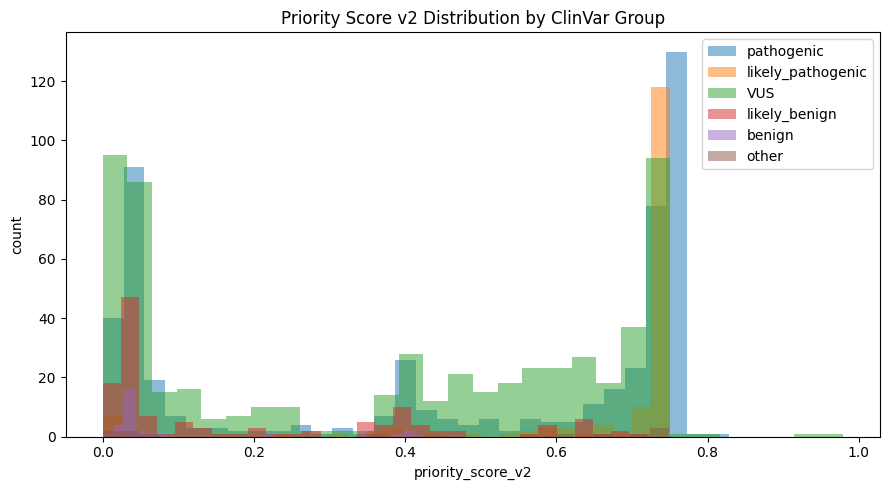

✅ Saved: cache_tp53/plot_priority_hist_by_group.png


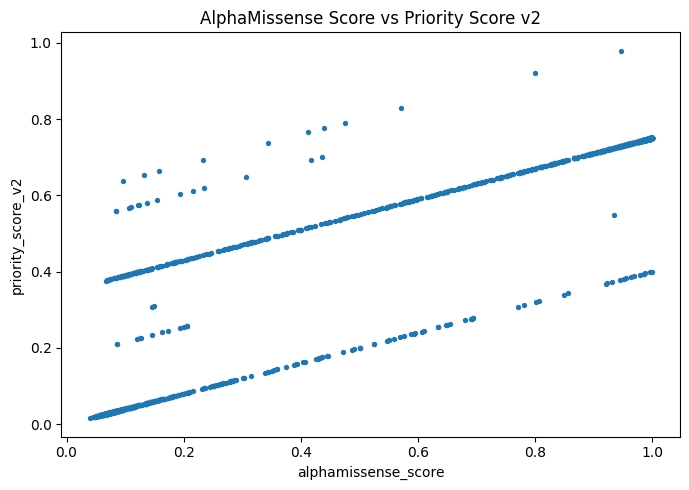

✅ Saved: cache_tp53/plot_am_vs_priority.png
Done ✅


In [13]:
# =========================
# CELL 12 — Generate plots (Histogram + Scatter) and save as PNG files
# =========================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

IN_FILE = os.path.join(CACHE_DIR, "tp53_final_missense_v2_with_domains.csv")
PLOT1 = os.path.join(CACHE_DIR, "plot_priority_hist_by_group.png")
PLOT2 = os.path.join(CACHE_DIR, "plot_am_vs_priority.png")

if not os.path.exists(IN_FILE):
    raise FileNotFoundError(f"Missing: {IN_FILE}. Run CELL 11 first.")

df = pd.read_csv(IN_FILE)

# --- Plot 1: Histogram of priority_score_v2 by clin_group ---
groups = ["pathogenic", "likely_pathogenic", "VUS", "likely_benign", "benign", "other"]
df["clin_group"] = df["clin_group"].astype(str)

plt.figure(figsize=(9,5))
for g in groups:
    sub = df[df["clin_group"] == g]
    if len(sub) == 0:
        continue
    plt.hist(pd.to_numeric(sub["priority_score_v2"], errors="coerce").dropna(), bins=30, alpha=0.5, label=g)

plt.title("Priority Score v2 Distribution by ClinVar Group")
plt.xlabel("priority_score_v2")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.savefig(PLOT1, dpi=200)
plt.show()
print("✅ Saved:", PLOT1)

# --- Plot 2: Scatter AlphaMissense score vs priority_score_v2 ---
x = pd.to_numeric(df["alphamissense_score"], errors="coerce")
y = pd.to_numeric(df["priority_score_v2"], errors="coerce")

mask = x.notna() & y.notna()

plt.figure(figsize=(7,5))
plt.scatter(x[mask], y[mask], s=8)
plt.title("AlphaMissense Score vs Priority Score v2")
plt.xlabel("alphamissense_score")
plt.ylabel("priority_score_v2")
plt.tight_layout()
plt.savefig(PLOT2, dpi=200)
plt.show()
print("✅ Saved:", PLOT2)

print("Done ✅")


In [14]:
# =========================
# CELL 13 — Export final outputs as ZIP for easy download
# =========================
import os, glob, zipfile

ZIP_PATH = os.path.join(CACHE_DIR, "tp53_outputs_v2.zip")

files_to_zip = [
    os.path.join(CACHE_DIR, "tp53_clinvar_grch38.csv"),
    os.path.join(CACHE_DIR, "pred_df_vep_tp53.csv"),
    os.path.join(CACHE_DIR, "tp53_missense_merged.csv"),
    os.path.join(CACHE_DIR, "tp53_missense_ready_for_alphamissense.csv"),
    os.path.join(CACHE_DIR, "alphamissense_tp53_clean.csv"),
    os.path.join(CACHE_DIR, "tp53_final_missense_v2.csv"),
    os.path.join(CACHE_DIR, "tp53_final_missense_v2_with_domains.csv"),
    os.path.join(CACHE_DIR, "summary_by_group_v2.csv"),
    os.path.join(CACHE_DIR, "summary_by_domain_v2.csv"),
    os.path.join(CACHE_DIR, "top50_vus_v2.csv"),
    os.path.join(CACHE_DIR, "plot_priority_hist_by_group.png"),
    os.path.join(CACHE_DIR, "plot_am_vs_priority.png"),
]

# keep only existing
files_to_zip = [p for p in files_to_zip if os.path.exists(p)]

with zipfile.ZipFile(ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for p in files_to_zip:
        z.write(p, arcname=os.path.basename(p))

print("✅ ZIP saved:", ZIP_PATH)
print("Included files:")
for p in files_to_zip:
    print(" -", os.path.basename(p))

# Optional: list cache directory
print("\nCache folder listing:")
for p in sorted(glob.glob(os.path.join(CACHE_DIR, "*"))):
    print(f"{os.path.basename(p):45s} {os.path.getsize(p)/1e6:8.1f} MB")


✅ ZIP saved: cache_tp53/tp53_outputs_v2.zip
Included files:
 - tp53_clinvar_grch38.csv
 - pred_df_vep_tp53.csv
 - tp53_missense_merged.csv
 - tp53_missense_ready_for_alphamissense.csv
 - alphamissense_tp53_clean.csv
 - tp53_final_missense_v2.csv
 - tp53_final_missense_v2_with_domains.csv
 - summary_by_group_v2.csv
 - summary_by_domain_v2.csv
 - top50_vus_v2.csv
 - plot_priority_hist_by_group.png
 - plot_am_vs_priority.png

Cache folder listing:
AlphaMissense_aa_substitutions.tsv.gz           1207.3 MB
alphamissense_tp53_clean.csv                       0.2 MB
plot_am_vs_priority.png                            0.1 MB
plot_priority_hist_by_group.png                    0.1 MB
pred_df_vep_tp53.csv                               0.1 MB
summary_by_domain_v2.csv                           0.0 MB
summary_by_group_v2.csv                            0.0 MB
top50_vus_v2.csv                                   0.0 MB
tp53_clinvar_grch38.csv                            0.2 MB
tp53_final_missense_v2.csv   

In [15]:
# =========================
# CELL 15 — Install tools for MSA & conservation
# =========================
!pip -q install biopython
!apt-get -qq update
!apt-get -qq install -y clustalo

import Bio, shutil
print("BioPython:", Bio.__version__)
print("clustalo path:", shutil.which("clustalo"))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 17.1 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libargtable2-0.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../libargtable2-0_13-1.1_amd64.deb ...
Unpacking libargtable2-0 (13-1.1) ...
Selecting previously unselected package clustalo.
Preparing to unpack .../clustalo_1.2.4-7_amd64.deb ...
Unpacking clustalo (1.2.4-7) ...
Setting up libargtable2-0 (13-1.1) ...
Setting up clustalo (1.2.4-7) ...
Processing triggers for libc-bin (2.35-0ubuntu3.11) ...
/sbin/ldconfig.real: /usr/local/lib/libhwloc.so.15 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_5.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind.so.3 is not a symbolic link

/sbin/ldc

In [16]:
# =========================
# CELL 16 — Fetch TP53 ortholog protein sequences from UniProt + write FASTA
# =========================
import os, textwrap
import requests

MSA_DIR = os.path.join(CACHE_DIR, "msa")
os.makedirs(MSA_DIR, exist_ok=True)

FASTA_PATH = os.path.join(MSA_DIR, "tp53_orthologs.fasta")

# UniProt query:
# - human TP53 (P04637)
# - plus reviewed orthologs that map to human TP53 (common approach for conservation MSA)
# Note: we keep it modest in size to keep Clustal Omega fast.
query = '(reviewed:true) AND (gene:TP53) AND (length:[350 TO 450])'

url = "https://rest.uniprot.org/uniprotkb/stream"
params = {
    "query": query,
    "format": "fasta",
    "compressed": "false",
    "size": 200  # max sequences to return (we will sample later)
}

r = requests.get(url, params=params, timeout=120)
r.raise_for_status()

fasta_text = r.text.strip()
if len(fasta_text) < 1000:
    raise ValueError("Fetched FASTA looks too small. UniProt request may have failed unexpectedly.")

# Save raw
RAW_FASTA = os.path.join(MSA_DIR, "tp53_uniprot_raw.fasta")
with open(RAW_FASTA, "w") as f:
    f.write(fasta_text + "\n")

print("✅ Saved raw FASTA:", RAW_FASTA)
print("Raw FASTA chars:", len(fasta_text))

# Keep a subset for speed: take the first N sequences (still multi-species)
N_KEEP = 60
seqs = fasta_text.split(">")[1:]
seqs = seqs[:N_KEEP]

with open(FASTA_PATH, "w") as f:
    for s in seqs:
        f.write(">" + s.strip() + "\n")

print("✅ Saved FASTA for MSA:", FASTA_PATH)
print("Sequences kept:", len(seqs))


✅ Saved raw FASTA: cache_tp53/msa/tp53_uniprot_raw.fasta
Raw FASTA chars: 14043
✅ Saved FASTA for MSA: cache_tp53/msa/tp53_orthologs.fasta
Sequences kept: 29


In [17]:
# =========================
# CELL 17 — Run Clustal Omega to build TP53 MSA (FASTA -> aligned FASTA)
# =========================
import os, subprocess

MSA_DIR = os.path.join(CACHE_DIR, "msa")
FASTA_PATH = os.path.join(MSA_DIR, "tp53_orthologs.fasta")
ALN_PATH = os.path.join(MSA_DIR, "tp53_orthologs_aligned.fasta")

if not os.path.exists(FASTA_PATH):
    raise FileNotFoundError(f"Missing: {FASTA_PATH}. Run CELL 16 first.")

cmd = [
    "clustalo",
    "-i", FASTA_PATH,
    "-o", ALN_PATH,
    "--force",
    "--outfmt", "fasta",
    "--threads", "2"
]

print("Running:", " ".join(cmd))
subprocess.run(cmd, check=True)

print("✅ Saved alignment:", ALN_PATH)
print("Alignment size (MB):", os.path.getsize(ALN_PATH)/1e6)


Running: clustalo -i cache_tp53/msa/tp53_orthologs.fasta -o cache_tp53/msa/tp53_orthologs_aligned.fasta --force --outfmt fasta --threads 2
✅ Saved alignment: cache_tp53/msa/tp53_orthologs_aligned.fasta
Alignment size (MB): 0.015333


In [18]:
# =========================
# CELL 18 — Compute conservation score per human TP53 position (0..1) from MSA
#           and save as CSV: tp53_conservation_by_position.csv
# =========================
import os
import pandas as pd
import numpy as np
from Bio import AlignIO

MSA_DIR = os.path.join(CACHE_DIR, "msa")
ALN_PATH = os.path.join(MSA_DIR, "tp53_orthologs_aligned.fasta")
CONS_CSV = os.path.join(MSA_DIR, "tp53_conservation_by_position.csv")

if not os.path.exists(ALN_PATH):
    raise FileNotFoundError(f"Missing: {ALN_PATH}. Run CELL 17 first.")

aln = AlignIO.read(ALN_PATH, "fasta")
records = list(aln)

# pick the human sequence as the one that contains "P04637" OR "Homo sapiens" OR "TP53_HUMAN"
def is_human(rec_id):
    s = rec_id.upper()
    return ("P04637" in s) or ("HOMO" in s and "SAPIENS" in s) or ("TP53_HUMAN" in s)

human_idx = None
for i, rec in enumerate(records):
    if is_human(rec.id) or is_human(rec.description):
        human_idx = i
        break

if human_idx is None:
    # fallback: use first sequence
    human_idx = 0
    print("⚠️ Human sequence not detected; using first sequence as reference:", records[0].id)
else:
    print("✅ Human sequence detected:", records[human_idx].id)

human_seq = str(records[human_idx].seq)
L = aln.get_alignment_length()

# Map alignment columns -> human residue position (1-based), skipping gaps in human
col_to_pos = {}
pos = 0
for col in range(L):
    aa = human_seq[col]
    if aa != "-":
        pos += 1
        col_to_pos[col] = pos

# Conservation: fraction of non-gap residues that match the human residue at that position
rows = []
for col, pos in col_to_pos.items():
    human_aa = human_seq[col]
    if human_aa == "-":
        continue

    col_chars = [str(r.seq[col]) for r in records]
    # exclude gaps and unknowns
    valid = [c for c in col_chars if c not in ("-", "X", "x", "?", "")]
    if len(valid) == 0:
        cons = np.nan
    else:
        matches = sum(1 for c in valid if c == human_aa)
        cons = matches / len(valid)

    rows.append({"position": pos, "human_aa": human_aa, "conservation": cons, "n_valid": len(valid)})

cons_df = pd.DataFrame(rows).sort_values("position")
cons_df.to_csv(CONS_CSV, index=False)

print("✅ Saved:", CONS_CSV)
print("Human length (positions):", cons_df["position"].max())
print(cons_df.head(5))
print(cons_df.tail(5))


✅ Human sequence detected: sp|P04637|P53_HUMAN
✅ Saved: cache_tp53/msa/tp53_conservation_by_position.csv
Human length (positions): 393
   position human_aa  conservation  n_valid
0         1        M      1.000000       24
1         2        E      0.769231       26
2         3        E      0.846154       26
3         4        P      0.478261       23
4         5        Q      0.826087       23
     position human_aa  conservation  n_valid
388       389        G      0.750000       28
389       390        P      0.666667       27
390       391        D      0.962963       27
391       392        S      0.962963       27
392       393        D      0.925926       27


In [19]:
# =========================
# CELL 19 — Merge conservation into final dataset + recompute priority_score_v3
# =========================
import os
import pandas as pd
import numpy as np

FINAL_DOMAINS = os.path.join(CACHE_DIR, "tp53_final_missense_v2_with_domains.csv")
CONS_CSV = os.path.join(CACHE_DIR, "msa", "tp53_conservation_by_position.csv")

OUT_FINAL_V3 = os.path.join(CACHE_DIR, "tp53_final_missense_v3.csv")
OUT_TOP50_VUS_V3 = os.path.join(CACHE_DIR, "top50_vus_v3.csv")
OUT_SUMMARY_V3 = os.path.join(CACHE_DIR, "summary_by_group_v3.csv")

if not os.path.exists(FINAL_DOMAINS):
    raise FileNotFoundError(f"Missing: {FINAL_DOMAINS}. Run CELL 11 first.")
if not os.path.exists(CONS_CSV):
    raise FileNotFoundError(f"Missing: {CONS_CSV}. Run CELL 18 first.")

df = pd.read_csv(FINAL_DOMAINS)
cons = pd.read_csv(CONS_CSV)

# merge by protein position
df["aa_position"] = pd.to_numeric(df.get("position", np.nan), errors="coerce")
cons["position"] = pd.to_numeric(cons["position"], errors="coerce")

merged = df.merge(cons[["position", "conservation"]], left_on="aa_position", right_on="position", how="left")
merged.drop(columns=["position"], inplace=True, errors="ignore")

print("Rows:", len(merged))
print("Conservation coverage:", merged["conservation"].notna().mean())

# Physicochemical placeholders are coming next cell; for now, compute v3 with conservation included
# Priority score v3 = v2 + conservation weight
am_score = pd.to_numeric(merged["alphamissense_score"], errors="coerce").fillna(0.0).clip(0, 1)
cons_score = pd.to_numeric(merged["conservation"], errors="coerce").fillna(0.0).clip(0, 1)

merged["priority_score_v3"] = (
    0.30 * merged["sift_comp"] +
    0.20 * merged["polyphen_comp"] +
    0.35 * am_score +
    0.15 * cons_score
)

merged.to_csv(OUT_FINAL_V3, index=False)
print("✅ Saved:", OUT_FINAL_V3)

# Summary by clin_group
summary = merged.groupby("clin_group", dropna=False).agg(
    n=("hgvsp_key", "count"),
    mean_priority=("priority_score_v3", "mean"),
    median_priority=("priority_score_v3", "median"),
    conservation_coverage=("conservation", lambda s: float(pd.to_numeric(s, errors="coerce").notna().mean())),
    am_coverage=("alphamissense_score", lambda s: float(pd.to_numeric(s, errors="coerce").notna().mean())),
).reset_index()

summary.to_csv(OUT_SUMMARY_V3, index=False)
print("✅ Saved:", OUT_SUMMARY_V3)
print(summary)

# Top 50 VUS
top_vus = merged[merged["clin_group"].astype(str).eq("VUS")].sort_values(
    "priority_score_v3", ascending=False
).head(50)

top_vus.to_csv(OUT_TOP50_VUS_V3, index=False)
print("✅ Saved:", OUT_TOP50_VUS_V3)
print(top_vus[["hgvsp_key","priority_score_v3","conservation","alphamissense_score"]].head(10))


Rows: 1434
Conservation coverage: 0.9944211994421199
✅ Saved: cache_tp53/tp53_final_missense_v3.csv
✅ Saved: cache_tp53/summary_by_group_v3.csv
          clin_group    n  mean_priority  median_priority  \
0                VUS  585       0.440810         0.479478   
1             benign   31       0.173956         0.121324   
2      likely_benign  132       0.264147         0.151066   
3  likely_pathogenic  160       0.726829         0.786682   
4              other   12       0.440619         0.539918   
5         pathogenic  514       0.517252         0.676584   

   conservation_coverage  am_coverage  
0               0.998291     0.986325  
1               1.000000     0.935484  
2               0.977273     0.871212  
3               0.993750     0.956250  
4               0.833333     0.750000  
5               0.998054     0.994163  
✅ Saved: cache_tp53/top50_vus_v3.csv
     hgvsp_key  priority_score_v3  conservation  alphamissense_score
963     p.S15R           0.960970      0.8

In [20]:
# =========================
# CELL 20 — Physicochemical change features (charge/polarity/size/hydropathy) + priority_score_v4
# =========================
import os
import pandas as pd
import numpy as np

IN_V3 = os.path.join(CACHE_DIR, "tp53_final_missense_v3.csv")
OUT_V4 = os.path.join(CACHE_DIR, "tp53_final_missense_v4.csv")
OUT_TOP50_VUS_V4 = os.path.join(CACHE_DIR, "top50_vus_v4.csv")
OUT_SUMMARY_V4 = os.path.join(CACHE_DIR, "summary_by_group_v4.csv")

if not os.path.exists(IN_V3):
    raise FileNotFoundError(f"Missing: {IN_V3}. Run CELL 19 first.")

df = pd.read_csv(IN_V3)

# Basic AA properties (simple, interpretable)
charge = {
    "D": -1, "E": -1,
    "K": +1, "R": +1, "H": +0.5,
    "A": 0, "C": 0, "F": 0, "G": 0, "I": 0, "L": 0, "M": 0, "N": 0, "P": 0, "Q": 0, "S": 0, "T": 0, "V": 0, "W": 0, "Y": 0
}
polarity = {  # 1=polar, 0=nonpolar (simple)
    "S":1,"T":1,"N":1,"Q":1,"Y":1,"C":1,"W":1,
    "D":1,"E":1,"K":1,"R":1,"H":1,
    "A":0,"V":0,"L":0,"I":0,"M":0,"F":0,"P":0,"G":0
}
size = {  # small=0, medium=0.5, large=1 (coarse)
    "G":0,"A":0,"S":0,"C":0,"P":0,"T":0,"D":0,"N":0,
    "V":0.5,"E":0.5,"Q":0.5,"H":0.5,"L":0.5,"I":0.5,"M":0.5,"K":0.5,
    "F":1,"Y":1,"R":1,"W":1
}
# Kyte-Doolittle hydropathy (standard values)
hydro = {
    "A":1.8,"C":2.5,"D":-3.5,"E":-3.5,"F":2.8,"G":-0.4,"H":-3.2,"I":4.5,"K":-3.9,"L":3.8,
    "M":1.9,"N":-3.5,"P":-1.6,"Q":-3.5,"R":-4.5,"S":-0.8,"T":-0.7,"V":4.2,"W":-0.9,"Y":-1.3
}

def prop_delta(ref, alt, table, default=np.nan):
    if pd.isna(ref) or pd.isna(alt):
        return default
    r = str(ref).strip().upper()
    a = str(alt).strip().upper()
    if r not in table or a not in table:
        return default
    return float(table[a]) - float(table[r])

# Ensure ref_aa/alt_aa
df["ref_aa"] = df.get("ref_aa", np.nan)
df["alt_aa"] = df.get("alt_aa", np.nan)

df["d_charge"] = df.apply(lambda x: prop_delta(x["ref_aa"], x["alt_aa"], charge), axis=1)
df["d_polarity"] = df.apply(lambda x: prop_delta(x["ref_aa"], x["alt_aa"], polarity), axis=1)
df["d_size"] = df.apply(lambda x: prop_delta(x["ref_aa"], x["alt_aa"], size), axis=1)
df["d_hydropathy"] = df.apply(lambda x: prop_delta(x["ref_aa"], x["alt_aa"], hydro), axis=1)

# Magnitudes (absolute change)
df["abs_d_charge"] = df["d_charge"].abs()
df["abs_d_polarity"] = df["d_polarity"].abs()
df["abs_d_size"] = df["d_size"].abs()
df["abs_d_hydropathy"] = df["d_hydropathy"].abs()

# Normalize hydropathy change (typical range ~ -9..+9) -> 0..1
hyd_norm = (df["abs_d_hydropathy"].fillna(0.0) / 9.0).clip(0, 1)

# Physchem score (0..1)
physchem = (
    0.30 * df["abs_d_charge"].fillna(0.0).clip(0, 1) +
    0.20 * df["abs_d_polarity"].fillna(0.0).clip(0, 1) +
    0.20 * df["abs_d_size"].fillna(0.0).clip(0, 1) +
    0.30 * hyd_norm
).clip(0, 1)

df["physchem_score"] = physchem

# Final priority score v4 (includes physchem)
am_score = pd.to_numeric(df["alphamissense_score"], errors="coerce").fillna(0.0).clip(0, 1)
cons_score = pd.to_numeric(df.get("conservation", np.nan), errors="coerce").fillna(0.0).clip(0, 1)

df["priority_score_v4"] = (
    0.25 * df["sift_comp"] +
    0.15 * df["polyphen_comp"] +
    0.30 * am_score +
    0.15 * cons_score +
    0.15 * df["physchem_score"]
)

df.to_csv(OUT_V4, index=False)
print("✅ Saved:", OUT_V4)

# Summary
summary = df.groupby("clin_group", dropna=False).agg(
    n=("hgvsp_key", "count"),
    mean_priority=("priority_score_v4", "mean"),
    median_priority=("priority_score_v4", "median"),
    conservation_coverage=("conservation", lambda s: float(pd.to_numeric(s, errors="coerce").notna().mean())),
    physchem_coverage=("physchem_score", lambda s: float(pd.to_numeric(s, errors="coerce").notna().mean())),
    am_coverage=("alphamissense_score", lambda s: float(pd.to_numeric(s, errors="coerce").notna().mean())),
).reset_index()

summary.to_csv(OUT_SUMMARY_V4, index=False)
print("✅ Saved:", OUT_SUMMARY_V4)
print(summary)

# Top 50 VUS v4
top_vus = df[df["clin_group"].astype(str).eq("VUS")].sort_values(
    "priority_score_v4", ascending=False
).head(50)

top_vus.to_csv(OUT_TOP50_VUS_V4, index=False)
print("✅ Saved:", OUT_TOP50_VUS_V4)
print(top_vus[["hgvsp_key","priority_score_v4","conservation","physchem_score","alphamissense_score"]].head(10))


✅ Saved: cache_tp53/tp53_final_missense_v4.csv
✅ Saved: cache_tp53/summary_by_group_v4.csv
          clin_group    n  mean_priority  median_priority  \
0                VUS  585       0.441660         0.470551   
1             benign   31       0.205179         0.163606   
2      likely_benign  132       0.286273         0.209078   
3  likely_pathogenic  160       0.696873         0.733680   
4              other   12       0.426979         0.497128   
5         pathogenic  514       0.511475         0.626409   

   conservation_coverage  physchem_coverage  am_coverage  
0               0.998291                1.0     0.986325  
1               1.000000                1.0     0.935484  
2               0.977273                1.0     0.871212  
3               0.993750                1.0     0.956250  
4               0.833333                1.0     0.750000  
5               0.998054                1.0     0.994163  
✅ Saved: cache_tp53/top50_vus_v4.csv
     hgvsp_key  priority_score_

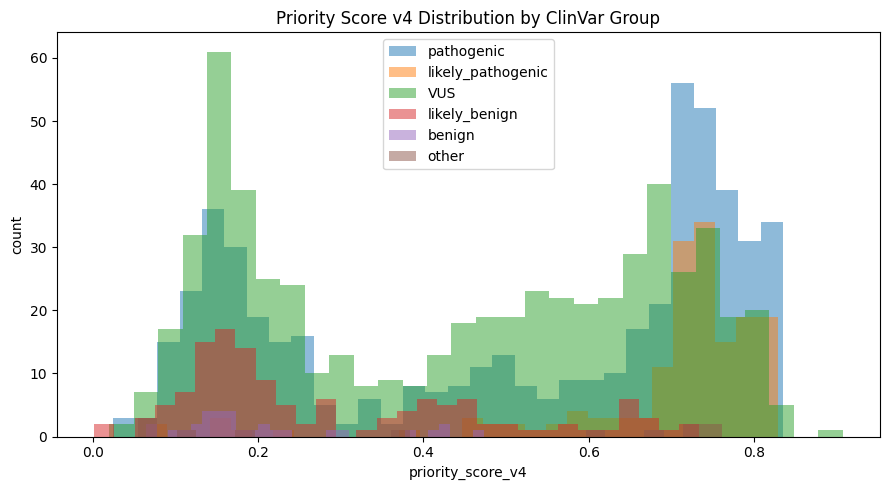

✅ Saved: cache_tp53/plot_priority_v4_hist_by_group.png


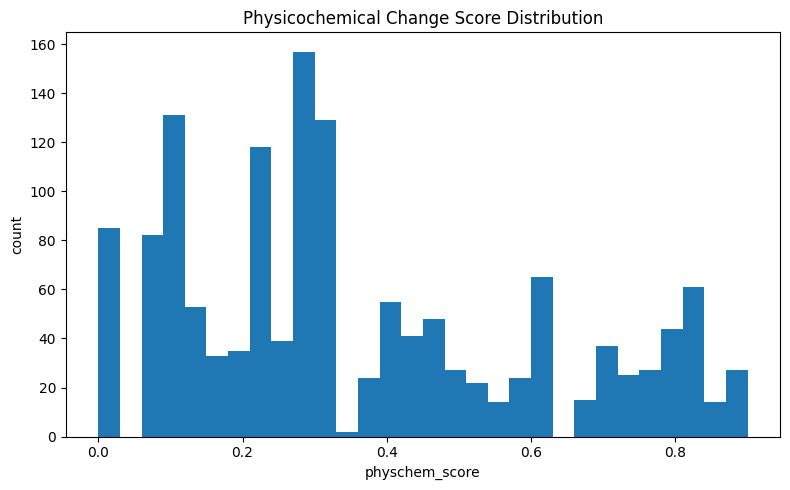

✅ Saved: cache_tp53/plot_physchem_hist.png


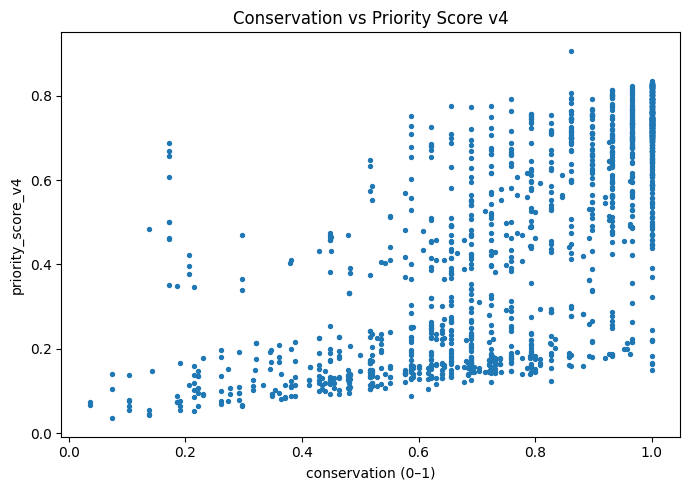

✅ Saved: cache_tp53/plot_conservation_vs_priority_v4.png


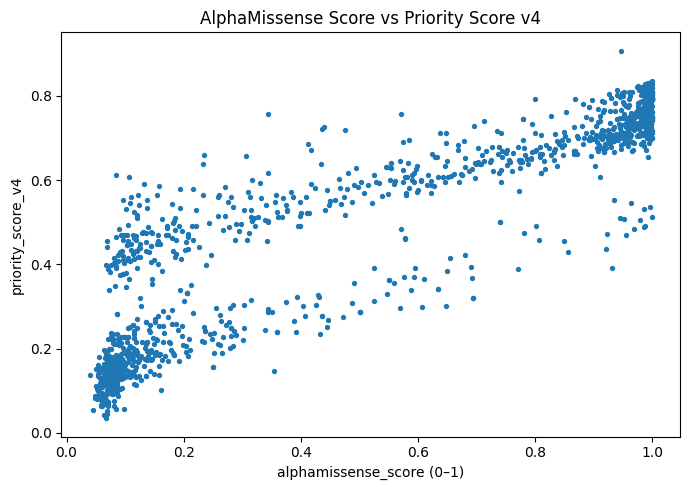

✅ Saved: cache_tp53/plot_alphamissense_vs_priority_v4.png
Done ✅


In [21]:
# =========================
# CELL 21 — Plots for v4 (histograms + scatters) and save PNGs
# =========================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

IN_V4 = os.path.join(CACHE_DIR, "tp53_final_missense_v4.csv")

P1 = os.path.join(CACHE_DIR, "plot_priority_v4_hist_by_group.png")
P2 = os.path.join(CACHE_DIR, "plot_physchem_hist.png")
P3 = os.path.join(CACHE_DIR, "plot_conservation_vs_priority_v4.png")
P4 = os.path.join(CACHE_DIR, "plot_alphamissense_vs_priority_v4.png")

if not os.path.exists(IN_V4):
    raise FileNotFoundError(f"Missing: {IN_V4}. Run CELL 20 first.")

df = pd.read_csv(IN_V4)
df["clin_group"] = df["clin_group"].astype(str)

groups = ["pathogenic", "likely_pathogenic", "VUS", "likely_benign", "benign", "other"]

# --- Plot 1: Histogram of priority_score_v4 by clin_group ---
plt.figure(figsize=(9,5))
for g in groups:
    sub = df[df["clin_group"] == g]
    if len(sub) == 0:
        continue
    vals = pd.to_numeric(sub["priority_score_v4"], errors="coerce").dropna()
    if len(vals) == 0:
        continue
    plt.hist(vals, bins=30, alpha=0.5, label=g)

plt.title("Priority Score v4 Distribution by ClinVar Group")
plt.xlabel("priority_score_v4")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.savefig(P1, dpi=200)
plt.show()
print("✅ Saved:", P1)

# --- Plot 2: Histogram of physchem_score ---
plt.figure(figsize=(8,5))
vals = pd.to_numeric(df["physchem_score"], errors="coerce").dropna()
plt.hist(vals, bins=30)
plt.title("Physicochemical Change Score Distribution")
plt.xlabel("physchem_score")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(P2, dpi=200)
plt.show()
print("✅ Saved:", P2)

# --- Plot 3: Scatter conservation vs priority_score_v4 ---
x = pd.to_numeric(df.get("conservation", np.nan), errors="coerce")
y = pd.to_numeric(df["priority_score_v4"], errors="coerce")
mask = x.notna() & y.notna()

plt.figure(figsize=(7,5))
plt.scatter(x[mask], y[mask], s=8)
plt.title("Conservation vs Priority Score v4")
plt.xlabel("conservation (0–1)")
plt.ylabel("priority_score_v4")
plt.tight_layout()
plt.savefig(P3, dpi=200)
plt.show()
print("✅ Saved:", P3)

# --- Plot 4: Scatter AlphaMissense vs priority_score_v4 ---
x = pd.to_numeric(df.get("alphamissense_score", np.nan), errors="coerce")
y = pd.to_numeric(df["priority_score_v4"], errors="coerce")
mask = x.notna() & y.notna()

plt.figure(figsize=(7,5))
plt.scatter(x[mask], y[mask], s=8)
plt.title("AlphaMissense Score vs Priority Score v4")
plt.xlabel("alphamissense_score (0–1)")
plt.ylabel("priority_score_v4")
plt.tight_layout()
plt.savefig(P4, dpi=200)
plt.show()
print("✅ Saved:", P4)

print("Done ✅")


In [22]:
# =========================
# CELL 23 — Boost PolyPhen coverage:
# Re-query VEP ONLY for variants where PolyPhen is missing, and choose the TC that has PolyPhen.
# Output: cache_tp53/pred_df_vep_tp53_polyfix.csv
# =========================
import os, time, json
import pandas as pd
import numpy as np
import requests
from tqdm import tqdm

if not os.path.exists(PRED_DF_CSV):
    raise FileNotFoundError(f"Missing: {PRED_DF_CSV}. Run CELL 5 first.")

pred = pd.read_csv(PRED_DF_CSV)

# Identify rows missing PolyPhen score
poly_missing_mask = pd.to_numeric(pred["polyphen_score"], errors="coerce").isna()
missing_rows = pred.loc[poly_missing_mask, "vep_row"].dropna().astype(str).tolist()

print("Total rows in pred_df:", len(pred))
print("PolyPhen missing rows to re-query:", len(missing_rows))

VEP_URL = "https://rest.ensembl.org/vep/human/region"
session = requests.Session()

def vep_post(batch):
    headers = {
        "Content-Type": "application/json",
        "Accept": "application/json",
        "User-Agent": "tp53-vus-prioritization-colab"
    }
    payload = {"variants": batch}
    backoff = 2
    for _ in range(8):
        r = session.post(VEP_URL, headers=headers, data=json.dumps(payload), timeout=180)
        if r.status_code == 429:
            time.sleep(backoff)
            backoff = min(backoff * 2, 60)
            continue
        r.raise_for_status()
        return r.json()
    raise RuntimeError("VEP request failed repeatedly.")

def tc_score(tc):
    # Prefer transcript consequences that actually provide PolyPhen/SIFT + protein mapping
    score = 0
    if tc.get("protein_start") is not None and tc.get("amino_acids"):
        score += 5
    if tc.get("polyphen_score") is not None:
        score += 100
    if tc.get("sift_score") is not None:
        score += 10
    if str(tc.get("canonical", "")).lower() in ("1", "true"):
        score += 3
    # Prefer missense consequence
    if "missense_variant" in (tc.get("consequence_terms") or []):
        score += 2
    return score

def pick_best_tc(tcs):
    if not tcs:
        return None
    # Sort by our scoring
    return max(tcs, key=tc_score)

def build_hgvsp(tc):
    h = tc.get("hgvsp")
    if isinstance(h, str) and h.startswith("p."):
        return h
    aa = tc.get("amino_acids")
    pos = tc.get("protein_start")
    if aa and pos:
        parts = str(aa).split("/")
        if len(parts) == 2:
            return f"p.{parts[0]}{int(pos)}{parts[1]}"
    return None

updates = []
batch_size = 200

for i in tqdm(range(0, len(missing_rows), batch_size), desc="VEP re-batches (polyfix)"):
    batch = missing_rows[i:i+batch_size]
    data = vep_post(batch)

    for entry in data:
        inp = entry.get("input")
        tcs = entry.get("transcript_consequences", []) or []
        is_missense = any("missense_variant" in (tc.get("consequence_terms") or []) for tc in tcs)

        best = pick_best_tc(tcs)
        rec = {
            "vep_row": inp,
            "is_missense": bool(is_missense),
            "position": None,
            "ref_aa": None,
            "alt_aa": None,
            "hgvsp": None,
            "sift_score": None,
            "sift_prediction": None,
            "polyphen_score": None,
            "polyphen_prediction": None,
        }

        if best:
            rec["position"] = best.get("protein_start")
            aa = best.get("amino_acids")
            if aa and "/" in str(aa):
                a0, a1 = str(aa).split("/", 1)
                rec["ref_aa"] = a0
                rec["alt_aa"] = a1

            rec["hgvsp"] = build_hgvsp(best)
            rec["sift_score"] = best.get("sift_score")
            rec["sift_prediction"] = best.get("sift_prediction")
            rec["polyphen_score"] = best.get("polyphen_score")
            rec["polyphen_prediction"] = best.get("polyphen_prediction")

        updates.append(rec)

updates_df = pd.DataFrame(updates).drop_duplicates(subset=["vep_row"])

# Apply updates back to pred
pred2 = pred.set_index("vep_row")
upd = updates_df.set_index("vep_row")

# Overwrite fields for those vep_rows
cols_to_overwrite = [
    "is_missense","position","ref_aa","alt_aa","hgvsp",
    "sift_score","sift_prediction","polyphen_score","polyphen_prediction"
]
for c in cols_to_overwrite:
    pred2.loc[upd.index, c] = upd[c]

pred2 = pred2.reset_index()

OUT_PRED_POLYFIX = os.path.join(CACHE_DIR, "pred_df_vep_tp53_polyfix.csv")
pred2.to_csv(OUT_PRED_POLYFIX, index=False)

# Requirement re-check
poly_nonmiss = int(pd.to_numeric(pred2["polyphen_score"], errors="coerce").notna().sum())
sift_nonmiss = int(pd.to_numeric(pred2["sift_score"], errors="coerce").notna().sum())

print("✅ Saved:", OUT_PRED_POLYFIX)
print("SIFT non-missing:", sift_nonmiss)
print("PolyPhen non-missing:", poly_nonmiss, "| meets ≥300:", (poly_nonmiss >= 300))
print(pred2.head(3))


Total rows in pred_df: 2698
PolyPhen missing rows to re-query: 2444


VEP re-batches (polyfix): 100%|██████████| 13/13 [01:05<00:00,  5.04s/it]

✅ Saved: cache_tp53/pred_df_vep_tp53_polyfix.csv
SIFT non-missing: 1432
PolyPhen non-missing: 1401 | meets ≥300: True
                  vep_row  is_missense  position ref_aa alt_aa    hgvsp  \
0  17 7674221 . G A . . .         True     248.0      R      W  p.R248W   
1  17 7674191 . C T . . .         True     258.0      E      K  p.E258K   
2  17 7674230 . C A . . .         True     245.0      G      C  p.G245C   

   sift_score sift_prediction  polyphen_score polyphen_prediction  
0         0.0     deleterious           1.000   probably_damaging  
1         0.0     deleterious           0.968   probably_damaging  
2         0.0     deleterious           1.000   probably_damaging  


In [23]:
# =========================
# CELL 24 — Rebuild final dataset using pred_df_vep_tp53_polyfix.csv (v4)
# Outputs:
#  - tp53_final_missense_v4_polyfix.csv
#  - top50_vus_v4_polyfix.csv
#  - summary_by_group_v4_polyfix.csv
# =========================
import os, re
import pandas as pd
import numpy as np

TP53_CLINVAR = os.path.join(CACHE_DIR, "tp53_clinvar_grch38.csv")
PRED_POLYFIX = os.path.join(CACHE_DIR, "pred_df_vep_tp53_polyfix.csv")
AM_TP53_CLEAN = os.path.join(CACHE_DIR, "alphamissense_tp53_clean.csv")
CONS_CSV = os.path.join(CACHE_DIR, "msa", "tp53_conservation_by_position.csv")

OUT_V4 = os.path.join(CACHE_DIR, "tp53_final_missense_v4_polyfix.csv")
OUT_TOP50 = os.path.join(CACHE_DIR, "top50_vus_v4_polyfix.csv")
OUT_SUMMARY = os.path.join(CACHE_DIR, "summary_by_group_v4_polyfix.csv")

for p in [TP53_CLINVAR, PRED_POLYFIX, AM_TP53_CLEAN, CONS_CSV]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing: {p}")

tp53 = pd.read_csv(TP53_CLINVAR)
pred = pd.read_csv(PRED_POLYFIX)
am = pd.read_csv(AM_TP53_CLEAN)
cons = pd.read_csv(CONS_CSV)

# Merge ClinVar + VEP
df = tp53.merge(pred, on="vep_row", how="left")

# Missense only + needs protein change key
df = df[(df["is_missense"] == True) & (df["hgvsp"].notna())].copy()

# hgvsp_key normalization (p.R248W)
pat = re.compile(r"(p\.[A-Za-z\*]+[0-9]+[A-Za-z\*]+)")
def norm_hgvsp(x):
    if pd.isna(x): return None
    m = pat.search(str(x).strip())
    return m.group(1) if m else None

df["hgvsp_key"] = df["hgvsp"].apply(norm_hgvsp)
df = df[df["hgvsp_key"].notna()].copy()

# Merge AlphaMissense
df = df.merge(am, on="hgvsp_key", how="left")

# Components for scoring
def sift_component(x):
    if pd.isna(x): return 0.0
    return 1.0 if "deleterious" in str(x).lower() else 0.0

def polyphen_component(x):
    if pd.isna(x): return 0.0
    s = str(x).lower()
    if "probably_damaging" in s: return 1.0
    if "possibly_damaging" in s: return 0.7
    if "benign" in s: return 0.0
    return 0.0

df["sift_comp"] = df["sift_prediction"].apply(sift_component)
df["polyphen_comp"] = df["polyphen_prediction"].apply(polyphen_component)

am_score = pd.to_numeric(df["alphamissense_score"], errors="coerce").fillna(0.0).clip(0, 1)

# Domain annotation (TP53 common ranges; UniProt TP53 P04637)
def map_domain(pos):
    if pd.isna(pos): return "unknown"
    p = int(float(pos))
    if 1 <= p <= 92: return "TAD"
    if 102 <= p <= 292: return "DBD"
    if 324 <= p <= 355: return "OD"
    return "other"

df["aa_position"] = pd.to_numeric(df.get("position", np.nan), errors="coerce")
df["domain"] = df["aa_position"].apply(map_domain)
df["in_core_domain"] = df["domain"].isin(["TAD", "DBD", "OD"])

# Merge conservation by position
cons["position"] = pd.to_numeric(cons["position"], errors="coerce")
df = df.merge(cons[["position", "conservation"]], left_on="aa_position", right_on="position", how="left")
df.drop(columns=["position"], inplace=True, errors="ignore")

cons_score = pd.to_numeric(df["conservation"], errors="coerce").fillna(0.0).clip(0, 1)

# Physicochemical features
charge = {"D":-1,"E":-1,"K":+1,"R":+1,"H":+0.5,
          "A":0,"C":0,"F":0,"G":0,"I":0,"L":0,"M":0,"N":0,"P":0,"Q":0,"S":0,"T":0,"V":0,"W":0,"Y":0}
polarity = {"S":1,"T":1,"N":1,"Q":1,"Y":1,"C":1,"W":1,"D":1,"E":1,"K":1,"R":1,"H":1,
            "A":0,"V":0,"L":0,"I":0,"M":0,"F":0,"P":0,"G":0}
size = {"G":0,"A":0,"S":0,"C":0,"P":0,"T":0,"D":0,"N":0,
        "V":0.5,"E":0.5,"Q":0.5,"H":0.5,"L":0.5,"I":0.5,"M":0.5,"K":0.5,
        "F":1,"Y":1,"R":1,"W":1}
hydro = {"A":1.8,"C":2.5,"D":-3.5,"E":-3.5,"F":2.8,"G":-0.4,"H":-3.2,"I":4.5,"K":-3.9,"L":3.8,
         "M":1.9,"N":-3.5,"P":-1.6,"Q":-3.5,"R":-4.5,"S":-0.8,"T":-0.7,"V":4.2,"W":-0.9,"Y":-1.3}

def delta(ref, alt, table):
    if pd.isna(ref) or pd.isna(alt): return np.nan
    r = str(ref).strip().upper()
    a = str(alt).strip().upper()
    if r not in table or a not in table: return np.nan
    return float(table[a]) - float(table[r])

df["d_charge"] = df.apply(lambda x: delta(x.get("ref_aa", np.nan), x.get("alt_aa", np.nan), charge), axis=1)
df["d_polarity"] = df.apply(lambda x: delta(x.get("ref_aa", np.nan), x.get("alt_aa", np.nan), polarity), axis=1)
df["d_size"] = df.apply(lambda x: delta(x.get("ref_aa", np.nan), x.get("alt_aa", np.nan), size), axis=1)
df["d_hydropathy"] = df.apply(lambda x: delta(x.get("ref_aa", np.nan), x.get("alt_aa", np.nan), hydro), axis=1)

df["abs_d_charge"] = df["d_charge"].abs()
df["abs_d_polarity"] = df["d_polarity"].abs()
df["abs_d_size"] = df["d_size"].abs()
df["abs_d_hydropathy"] = df["d_hydropathy"].abs()

hyd_norm = (df["abs_d_hydropathy"].fillna(0.0) / 9.0).clip(0, 1)
df["physchem_score"] = (
    0.30 * df["abs_d_charge"].fillna(0.0).clip(0, 1) +
    0.20 * df["abs_d_polarity"].fillna(0.0).clip(0, 1) +
    0.20 * df["abs_d_size"].fillna(0.0).clip(0, 1) +
    0.30 * hyd_norm
).clip(0, 1)

# Final v4 score (with improved PolyPhen)
df["priority_score_v4"] = (
    0.25 * df["sift_comp"] +
    0.15 * df["polyphen_comp"] +
    0.30 * am_score +
    0.15 * cons_score +
    0.15 * df["physchem_score"]
)

df.to_csv(OUT_V4, index=False)
print("✅ Saved:", OUT_V4, "| rows:", len(df))

# Requirement check (after rebuild)
sift_nonmiss = int(pd.to_numeric(df["sift_score"], errors="coerce").notna().sum())
poly_nonmiss = int(pd.to_numeric(df["polyphen_score"], errors="coerce").notna().sum())
print("SIFT non-missing:", sift_nonmiss, "| PolyPhen non-missing:", poly_nonmiss, "| PolyPhen ≥300:", (poly_nonmiss >= 300))

# Top 50 VUS
top_vus = df[df["clin_group"].astype(str).eq("VUS")].sort_values("priority_score_v4", ascending=False).head(50)
top_vus.to_csv(OUT_TOP50, index=False)
print("✅ Saved:", OUT_TOP50)

# Summary by group
summary = df.groupby("clin_group", dropna=False).agg(
    n=("hgvsp_key", "count"),
    mean_priority=("priority_score_v4", "mean"),
    median_priority=("priority_score_v4", "median"),
    sift_coverage=("sift_score", lambda s: float(pd.to_numeric(s, errors="coerce").notna().mean())),
    polyphen_coverage=("polyphen_score", lambda s: float(pd.to_numeric(s, errors="coerce").notna().mean())),
    am_coverage=("alphamissense_score", lambda s: float(pd.to_numeric(s, errors="coerce").notna().mean())),
    conservation_coverage=("conservation", lambda s: float(pd.to_numeric(s, errors="coerce").notna().mean())),
).reset_index()

summary.to_csv(OUT_SUMMARY, index=False)
print("✅ Saved:", OUT_SUMMARY)
print(summary)


✅ Saved: cache_tp53/tp53_final_missense_v4_polyfix.csv | rows: 1458
SIFT non-missing: 1431 | PolyPhen non-missing: 1400 | PolyPhen ≥300: True
✅ Saved: cache_tp53/top50_vus_v4_polyfix.csv
✅ Saved: cache_tp53/summary_by_group_v4_polyfix.csv
          clin_group    n  mean_priority  median_priority  sift_coverage  \
0                VUS  585       0.480016         0.491916       0.996581   
1             benign   35       0.205052         0.161000       0.971429   
2      likely_benign  149       0.286871         0.197000       0.906040   
3  likely_pathogenic  160       0.800779         0.866980       0.962500   
4              other   12       0.442717         0.483388       0.833333   
5         pathogenic  517       0.579208         0.669608       0.996132   

   polyphen_coverage  am_coverage  conservation_coverage  
0           0.993162     0.863248               0.998291  
1           0.857143     0.600000               1.000000  
2           0.778523     0.583893               0.9

In [24]:
# =========================
# CELL 25 — Comparison tables: BEFORE vs AFTER PolyPhen-fix
# Outputs:
#  - polyphen_fix_comparison_overall.csv
#  - polyphen_fix_comparison_by_group.csv
# =========================
import os
import pandas as pd
import numpy as np

OLD_V4 = os.path.join(CACHE_DIR, "tp53_final_missense_v4.csv")
NEW_V4 = os.path.join(CACHE_DIR, "tp53_final_missense_v4_polyfix.csv")

OLD_PRED = os.path.join(CACHE_DIR, "pred_df_vep_tp53.csv")
NEW_PRED = os.path.join(CACHE_DIR, "pred_df_vep_tp53_polyfix.csv")

OUT_OVERALL = os.path.join(CACHE_DIR, "polyphen_fix_comparison_overall.csv")
OUT_GROUP = os.path.join(CACHE_DIR, "polyphen_fix_comparison_by_group.csv")

def summarize(df, name):
    sift = pd.to_numeric(df.get("sift_score", np.nan), errors="coerce")
    poly = pd.to_numeric(df.get("polyphen_score", np.nan), errors="coerce")
    both = sift.notna() & poly.notna()
    return {
        "dataset": name,
        "rows": int(len(df)),
        "sift_nonmissing": int(sift.notna().sum()),
        "polyphen_nonmissing": int(poly.notna().sum()),
        "both_nonmissing": int(both.sum()),
        "sift_coverage": float(sift.notna().mean()),
        "polyphen_coverage": float(poly.notna().mean()),
        "both_coverage": float(both.mean()),
    }

# --- Overall comparison (final datasets) ---
overall_rows = []

if os.path.exists(OLD_V4):
    old_df = pd.read_csv(OLD_V4)
    overall_rows.append(summarize(old_df, "final_v4_before_polyfix"))
else:
    old_df = None
    print("OLD final_v4 not found (skipping):", OLD_V4)

new_df = pd.read_csv(NEW_V4)
overall_rows.append(summarize(new_df, "final_v4_after_polyfix"))

overall = pd.DataFrame(overall_rows)
overall.to_csv(OUT_OVERALL, index=False)
print("✅ Saved:", OUT_OVERALL)
print(overall)

# --- By-group comparison (only if old exists and clin_group exists) ---
if old_df is not None and "clin_group" in old_df.columns and "clin_group" in new_df.columns:
    def by_group(df, tag):
        sift = pd.to_numeric(df.get("sift_score", np.nan), errors="coerce")
        poly = pd.to_numeric(df.get("polyphen_score", np.nan), errors="coerce")
        tmp = df.copy()
        tmp["sift_avail"] = sift.notna()
        tmp["poly_avail"] = poly.notna()
        tmp["both_avail"] = sift.notna() & poly.notna()
        g = tmp.groupby("clin_group", dropna=False).agg(
            n=("hgvsp_key", "count") if "hgvsp_key" in tmp.columns else ("clin_group", "count"),
            sift_nonmissing=("sift_avail", "sum"),
            polyphen_nonmissing=("poly_avail", "sum"),
            both_nonmissing=("both_avail", "sum"),
        ).reset_index()
        g["sift_coverage"] = g["sift_nonmissing"] / g["n"]
        g["polyphen_coverage"] = g["polyphen_nonmissing"] / g["n"]
        g["both_coverage"] = g["both_nonmissing"] / g["n"]
        g["dataset"] = tag
        return g

    g_old = by_group(old_df, "before")
    g_new = by_group(new_df, "after")

    g = pd.concat([g_old, g_new], ignore_index=True)
    g.to_csv(OUT_GROUP, index=False)
    print("✅ Saved:", OUT_GROUP)
    print(g.head(10))
else:
    print("By-group comparison skipped (missing old file or clin_group).")

# --- Optional: Compare VEP pred tables (annotation-level) ---
if os.path.exists(OLD_PRED) and os.path.exists(NEW_PRED):
    op = pd.read_csv(OLD_PRED)
    npd = pd.read_csv(NEW_PRED)
    pred_comp = pd.DataFrame([
        summarize(op, "pred_df_before_polyfix"),
        summarize(npd, "pred_df_after_polyfix"),
    ])
    OUT_PRED_COMP = os.path.join(CACHE_DIR, "polyphen_fix_comparison_pred_df.csv")
    pred_comp.to_csv(OUT_PRED_COMP, index=False)
    print("✅ Saved:", OUT_PRED_COMP)
    print(pred_comp)


✅ Saved: cache_tp53/polyphen_fix_comparison_overall.csv
                   dataset  rows  sift_nonmissing  polyphen_nonmissing  \
0  final_v4_before_polyfix  1434             1416                  253   
1   final_v4_after_polyfix  1458             1431                 1400   

   both_nonmissing  sift_coverage  polyphen_coverage  both_coverage  
0              253       0.987448           0.176430       0.176430  
1             1400       0.981481           0.960219       0.960219  
✅ Saved: cache_tp53/polyphen_fix_comparison_by_group.csv
          clin_group    n  sift_nonmissing  polyphen_nonmissing  \
0                VUS  585              582                  125   
1             benign   31               31                   11   
2      likely_benign  132              127                   32   
3  likely_pathogenic  160              154                    0   
4              other   12               10                    0   
5         pathogenic  514              512          

/tmp/ipython-input-576517451.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


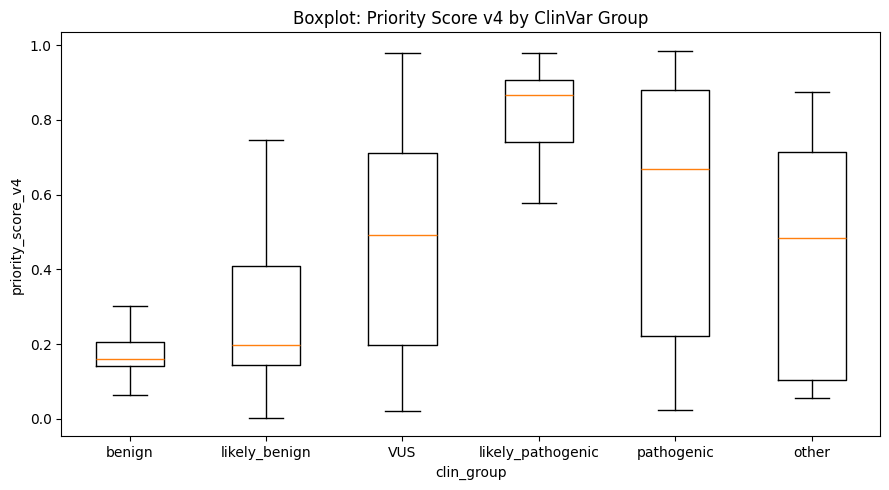

✅ Saved: cache_tp53/boxplot_priority_v4_by_group.png


/tmp/ipython-input-576517451.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


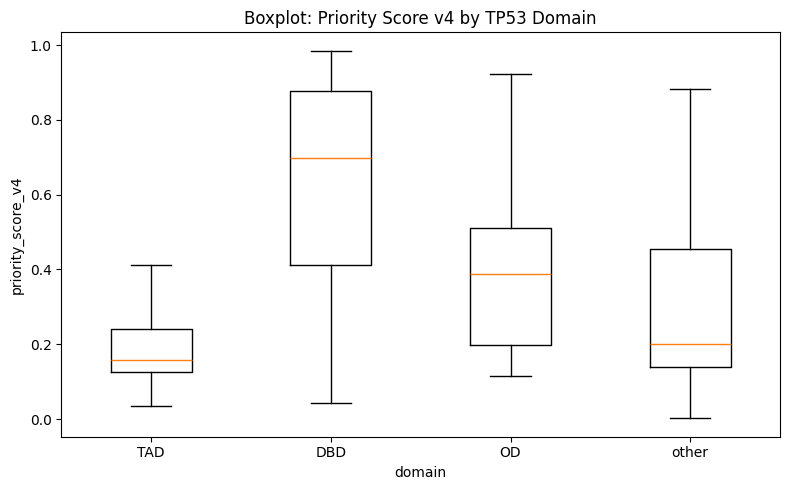

✅ Saved: cache_tp53/boxplot_priority_v4_by_domain.png


In [25]:
# =========================
# CELL 26 — Boxplots (priority_score_v4 by ClinVar group + by domain)
# Outputs:
#  - boxplot_priority_v4_by_group.png
#  - boxplot_priority_v4_by_domain.png
# =========================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

IN_FILE = os.path.join(CACHE_DIR, "tp53_final_missense_v4_polyfix.csv")

P_GROUP = os.path.join(CACHE_DIR, "boxplot_priority_v4_by_group.png")
P_DOMAIN = os.path.join(CACHE_DIR, "boxplot_priority_v4_by_domain.png")

if not os.path.exists(IN_FILE):
    raise FileNotFoundError(f"Missing: {IN_FILE}. Run CELL 24 first.")

df = pd.read_csv(IN_FILE)

# Clean columns
df["priority_score_v4"] = pd.to_numeric(df["priority_score_v4"], errors="coerce")
df["clin_group"] = df["clin_group"].astype(str)

# --- Boxplot by ClinVar group ---
order_groups = ["benign", "likely_benign", "VUS", "likely_pathogenic", "pathogenic", "other"]
data = []
labels = []
for g in order_groups:
    vals = df.loc[df["clin_group"] == g, "priority_score_v4"].dropna().values
    if len(vals) > 0:
        data.append(vals)
        labels.append(g)

plt.figure(figsize=(9,5))
plt.boxplot(data, labels=labels, showfliers=False)
plt.title("Boxplot: Priority Score v4 by ClinVar Group")
plt.xlabel("clin_group")
plt.ylabel("priority_score_v4")
plt.tight_layout()
plt.savefig(P_GROUP, dpi=200)
plt.show()
print("✅ Saved:", P_GROUP)

# --- Boxplot by domain ---
if "domain" not in df.columns:
    # If domain missing for any reason, rebuild it quickly from aa_position
    df["aa_position"] = pd.to_numeric(df.get("aa_position", df.get("position", np.nan)), errors="coerce")
    def map_domain(pos):
        if pd.isna(pos): return "unknown"
        p = int(float(pos))
        if 1 <= p <= 92: return "TAD"
        if 102 <= p <= 292: return "DBD"
        if 324 <= p <= 355: return "OD"
        return "other"
    df["domain"] = df["aa_position"].apply(map_domain)

order_domains = ["TAD", "DBD", "OD", "other"]
data = []
labels = []
for d in order_domains:
    vals = df.loc[df["domain"] == d, "priority_score_v4"].dropna().values
    if len(vals) > 0:
        data.append(vals)
        labels.append(d)

plt.figure(figsize=(8,5))
plt.boxplot(data, labels=labels, showfliers=False)
plt.title("Boxplot: Priority Score v4 by TP53 Domain")
plt.xlabel("domain")
plt.ylabel("priority_score_v4")
plt.tight_layout()
plt.savefig(P_DOMAIN, dpi=200)
plt.show()
print("✅ Saved:", P_DOMAIN)


✅ Human detected: sp|P04637|P53_HUMAN
✅ Saved: cache_tp53/msa/tp53_conservation_by_position_majority.csv
Human length: 393


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

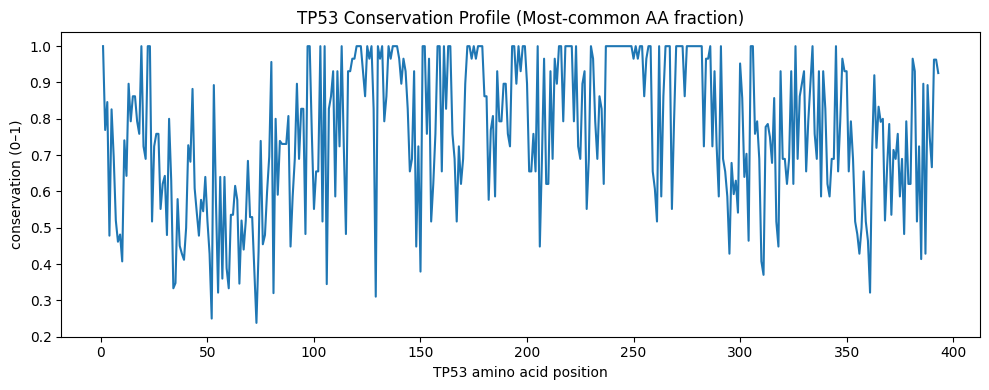

In [26]:
# =========================
# CELL 28 — Recompute conservation as "most common amino acid fraction" (0..1)
#           + save conservation profile plot
# Outputs:
#  - cache_tp53/msa/tp53_conservation_by_position_majority.csv
#  - cache_tp53/plot_conservation_profile_majority.png
# =========================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Bio import AlignIO

MSA_DIR = os.path.join(CACHE_DIR, "msa")
ALN_PATH = os.path.join(MSA_DIR, "tp53_orthologs_aligned.fasta")

CONS_MAJ = os.path.join(MSA_DIR, "tp53_conservation_by_position_majority.csv")
P_CONS = os.path.join(CACHE_DIR, "plot_conservation_profile_majority.png")

if not os.path.exists(ALN_PATH):
    raise FileNotFoundError(f"Missing: {ALN_PATH}. Run CELL 17 first.")

aln = AlignIO.read(ALN_PATH, "fasta")
records = list(aln)
L = aln.get_alignment_length()

def is_human(rec):
    s = (rec.id + " " + rec.description).upper()
    return ("P04637" in s) or ("HOMO" in s and "SAPIENS" in s) or ("TP53_HUMAN" in s)

human_idx = None
for i, rec in enumerate(records):
    if is_human(rec):
        human_idx = i
        break
if human_idx is None:
    human_idx = 0
    print("⚠️ Human not detected; using first sequence as reference:", records[0].id)
else:
    print("✅ Human detected:", records[human_idx].id)

human_seq = str(records[human_idx].seq)

# Map alignment columns -> human residue position (1-based), skipping gaps in human
col_to_pos = {}
pos = 0
for col in range(L):
    if human_seq[col] != "-":
        pos += 1
        col_to_pos[col] = pos

rows = []
for col, pos in col_to_pos.items():
    col_chars = [str(r.seq[col]) for r in records]
    valid = [c for c in col_chars if c not in ("-", "X", "x", "?", "")]
    if len(valid) == 0:
        cons = np.nan
        mode_aa = None
    else:
        vc = pd.Series(valid).value_counts()
        mode_aa = str(vc.index[0])
        cons = float(vc.iloc[0] / len(valid))  # MOST COMMON AA fraction (per plan)

    rows.append({
        "position": pos,
        "human_aa": human_seq[col],
        "most_common_aa": mode_aa,
        "conservation_majority": cons,
        "n_valid": len(valid),
    })

cons_df = pd.DataFrame(rows).sort_values("position")
cons_df.to_csv(CONS_MAJ, index=False)
print("✅ Saved:", CONS_MAJ)
print("Human length:", int(cons_df["position"].max()))

# Plot conservation profile
plt.figure(figsize=(10,4))
plt.plot(cons_df["position"], cons_df["conservation_majority"])
plt.title("TP53 Conservation Profile (Most-common AA fraction)")
plt.xlabel("TP53 amino acid position")
plt.ylabel("conservation (0–1)")
plt.tight_layout()
plt


In [27]:
# =========================
# CELL 29 — Merge majority-conservation into final dataset + recompute priority_score_v4_majority
# Outputs:
#  - cache_tp53/tp53_final_missense_v4_polyfix_majority.csv
#  - cache_tp53/top50_vus_v4_polyfix_majority.csv
#  - cache_tp53/summary_by_group_v4_polyfix_majority.csv
# =========================
import os
import pandas as pd
import numpy as np

IN_FINAL = os.path.join(CACHE_DIR, "tp53_final_missense_v4_polyfix.csv")
CONS_MAJ = os.path.join(CACHE_DIR, "msa", "tp53_conservation_by_position_majority.csv")

OUT_FINAL = os.path.join(CACHE_DIR, "tp53_final_missense_v4_polyfix_majority.csv")
OUT_TOP50 = os.path.join(CACHE_DIR, "top50_vus_v4_polyfix_majority.csv")
OUT_SUMMARY = os.path.join(CACHE_DIR, "summary_by_group_v4_polyfix_majority.csv")

if not os.path.exists(IN_FINAL):
    raise FileNotFoundError(f"Missing: {IN_FINAL}. Run CELL 24 first.")
if not os.path.exists(CONS_MAJ):
    raise FileNotFoundError(f"Missing: {CONS_MAJ}. Run CELL 28 first.")

df = pd.read_csv(IN_FINAL)
cons = pd.read_csv(CONS_MAJ)

# Merge by aa position
df["aa_position"] = pd.to_numeric(df.get("aa_position", df.get("position", np.nan)), errors="coerce")
cons["position"] = pd.to_numeric(cons["position"], errors="coerce")

df2 = df.merge(
    cons[["position", "conservation_majority", "most_common_aa"]],
    left_on="aa_position", right_on="position", how="left"
).drop(columns=["position"], errors="ignore")

# Recompute score using majority conservation (instead of previous conservation)
am_score = pd.to_numeric(df2.get("alphamissense_score", np.nan), errors="coerce").fillna(0.0).clip(0, 1)
cons_score = pd.to_numeric(df2.get("conservation_majority", np.nan), errors="coerce").fillna(0.0).clip(0, 1)

df2["priority_score_v4_majority"] = (
    0.25 * df2["sift_comp"] +
    0.15 * df2["polyphen_comp"] +
    0.30 * am_score +
    0.15 * cons_score +
    0.15 * pd.to_numeric(df2.get("physchem_score", 0.0), errors="coerce").fillna(0.0).clip(0, 1)
)

df2.to_csv(OUT_FINAL, index=False)
print("✅ Saved:", OUT_FINAL, "| rows:", len(df2))
print("Majority conservation coverage:", df2["conservation_majority"].notna().mean())

# Top 50 VUS
top_vus = df2[df2["clin_group"].astype(str).eq("VUS")].sort_values(
    "priority_score_v4_majority", ascending=False
).head(50)
top_vus.to_csv(OUT_TOP50, index=False)
print("✅ Saved:", OUT_TOP50)

# Summary
summary = df2.groupby("clin_group", dropna=False).agg(
    n=("hgvsp_key", "count") if "hgvsp_key" in df2.columns else ("clin_group", "count"),
    mean_priority=("priority_score_v4_majority", "mean"),
    median_priority=("priority_score_v4_majority", "median"),
    sift_coverage=("sift_score", lambda s: float(pd.to_numeric(s, errors="coerce").notna().mean())),
    polyphen_coverage=("polyphen_score", lambda s: float(pd.to_numeric(s, errors="coerce").notna().mean())),
    am_coverage=("alphamissense_score", lambda s: float(pd.to_numeric(s, errors="coerce").notna().mean())),
    majority_conservation_coverage=("conservation_majority", lambda s: float(pd.to_numeric(s, errors="coerce").notna().mean())),
).reset_index()

summary.to_csv(OUT_SUMMARY, index=False)
print("✅ Saved:", OUT_SUMMARY)
print(summary)


✅ Saved: cache_tp53/tp53_final_missense_v4_polyfix_majority.csv | rows: 1458
Majority conservation coverage: 0.9945130315500685
✅ Saved: cache_tp53/top50_vus_v4_polyfix_majority.csv
✅ Saved: cache_tp53/summary_by_group_v4_polyfix_majority.csv
          clin_group    n  mean_priority  median_priority  sift_coverage  \
0                VUS  585       0.483360         0.493500       0.996581   
1             benign   35       0.207747         0.163606       0.971429   
2      likely_benign  149       0.290144         0.202418       0.906040   
3  likely_pathogenic  160       0.801381         0.866980       0.962500   
4              other   12       0.445304         0.483388       0.833333   
5         pathogenic  517       0.581664         0.670020       0.996132   

   polyphen_coverage  am_coverage  majority_conservation_coverage  
0           0.993162     0.863248                        0.998291  
1           0.857143     0.600000                        1.000000  
2           0.778523